# Figure 5: Qualitative Segmentation Results (GT vs. Prediction Overlay)

Representative qualitative segmentation results for ultrasound examples.
White contours = ground-truth annotations | Red contours = model predictions.

# Ground Truth ROI Overlay on Model Predictions

This notebook overlays ground truth ROI masks on model prediction images.

**Legend:**
- **P** = Arthritis (Positive) - true label
- **C** = Control - true label  
- **Green overlay** = Ground truth ROI

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Paths
BASE_DIR = Path('/home/zera/Desktop/data_fold/folds/folds')
PRED_DIR = BASE_DIR / 'output' / 'FOLD_1' / 'run_1' / 'final' / 'fold_test_predictions'
ROI_DIR = BASE_DIR / 'FOLD_1' / 'test' / 'ROI'
FIGURES_DIR = Path('/home/zera/Desktop/data_fold/test_evaluation_figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Prediction images to process
pred_images = [
    'image_005_R_P_001_pred_arthrit.png',
    'image_008_L_C_001_pred_control.png',
    'image_016_R_C_001_pred_control.png',
    'image_017_L_P_001_pred_arthrit.png'
]

print(f"Prediction directory: {PRED_DIR}")
print(f"ROI directory: {ROI_DIR}")
print(f"Figures directory: {FIGURES_DIR}")

Prediction directory: /home/zera/Desktop/data_fold/folds/folds/output/FOLD_1/run_1/final/fold_test_predictions
ROI directory: /home/zera/Desktop/data_fold/folds/folds/FOLD_1/test/ROI
Figures directory: /home/zera/Desktop/data_fold/test_evaluation_figures


## Helper Functions

In [ ]:
def parse_filename(filename):
    """
    Parse prediction filename to extract info
    Example: image_005_R_P_001_pred_arthrit.png
    """
    name = filename.replace('.png', '')
    parts = name.split('_')
    
    patient_num = parts[1]  # 005
    side = parts[2]  # R or L
    true_class = parts[3]  # P or C
    slice_num = parts[4]  # 001
    pred_class = parts[6]  # arthrit or control
    
    slice_name = f"{patient_num}_{side}_{true_class}_{slice_num}"
    
    return {
        'slice_name': slice_name,
        'true_class': 'Arthritis' if true_class == 'P' else 'Control',
        'pred_class': 'Arthritis' if pred_class == 'arthrit' else 'Control',
        'patient_id': f"{patient_num}_{side}_{true_class}"
    }


def load_images(pred_filename):
    """Load prediction image and ground truth ROI mask"""
    
    info = parse_filename(pred_filename)
    
    # Load prediction image
    pred_path = PRED_DIR / pred_filename
    if not pred_path.exists():
        print(f"Prediction not found: {pred_path}")
        return None, None, None
    
    pred_img = cv2.imread(str(pred_path))
    pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)
    
    # Load ground truth ROI mask
    roi_filename = f"mask_{info['slice_name']}.png"
    roi_path = ROI_DIR / roi_filename
    
    if not roi_path.exists():
        print(f"ROI mask not found: {roi_path}")
        return pred_img, None, info
    
    roi_mask = cv2.imread(str(roi_path), cv2.IMREAD_GRAYSCALE)
    
    return pred_img, roi_mask, info


def overlay_ground_truth(pred_img, roi_mask, alpha=0.3):
    """Overlay ground truth and prediction ROI on image as hollow contours"""
    
    overlay = pred_img.copy()
    
    # Gerçek (Ground Truth) kordinatları (Beyaz)
    if roi_mask is not None:
        gt_contours, _ = cv2.findContours(roi_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(overlay, gt_contours, -1, (255, 255, 255), 3) # White
        
    # Tahmin (Prediction) kordinatları (Kırmızı)
    # Note: pred_img already has green pixels burned into it from YOLO predictions by default.
    # We will extract those green pixels to find the prediction mask contour, and draw it red.
    hsv = cv2.cvtColor(pred_img, cv2.COLOR_RGB2HSV)
    # Define range of green color in HSV
    lower_green = np.array([35, 50, 50])
    upper_green = np.array([85, 255, 255])
    pred_mask = cv2.inRange(hsv, lower_green, upper_green)
    
    # Remove the filled green from the base image so it's hollow
    overlay[pred_mask > 0] = pred_img[pred_mask > 0] # Reset green to original (requires original but we modified the base so it will still be green unfortunately)
    # A trick: To really remove the green, we would need the raw image. Since pred_img HAS the green, we just draw thick red over the edges.
    
    pr_contours, _ = cv2.findContours(pred_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, pr_contours, -1, (255, 0, 0), 3) # Red in RGB
    
    # Legend
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.rectangle(overlay, (overlay.shape[1] - 250, 10), (overlay.shape[1] - 10, 70), (0, 0, 0), -1)
    cv2.putText(overlay, "White: Ground Truth", (overlay.shape[1] - 240, 35), font, 0.6, (255, 255, 255), 2)
    cv2.putText(overlay, "Red: Prediction", (overlay.shape[1] - 240, 60), font, 0.6, (255, 0, 0), 2)
    
    return overlay


Function `parse_filename` defined.


## Combined Comparison Figure

Shows all predictions side-by-side with ground truth ROI overlay.


Figure saved to: /home/zera/Desktop/data_fold/test_evaluation_figures/Figure_Prediction_vs_GroundTruth_ROI_BlueRed_Pairs.png


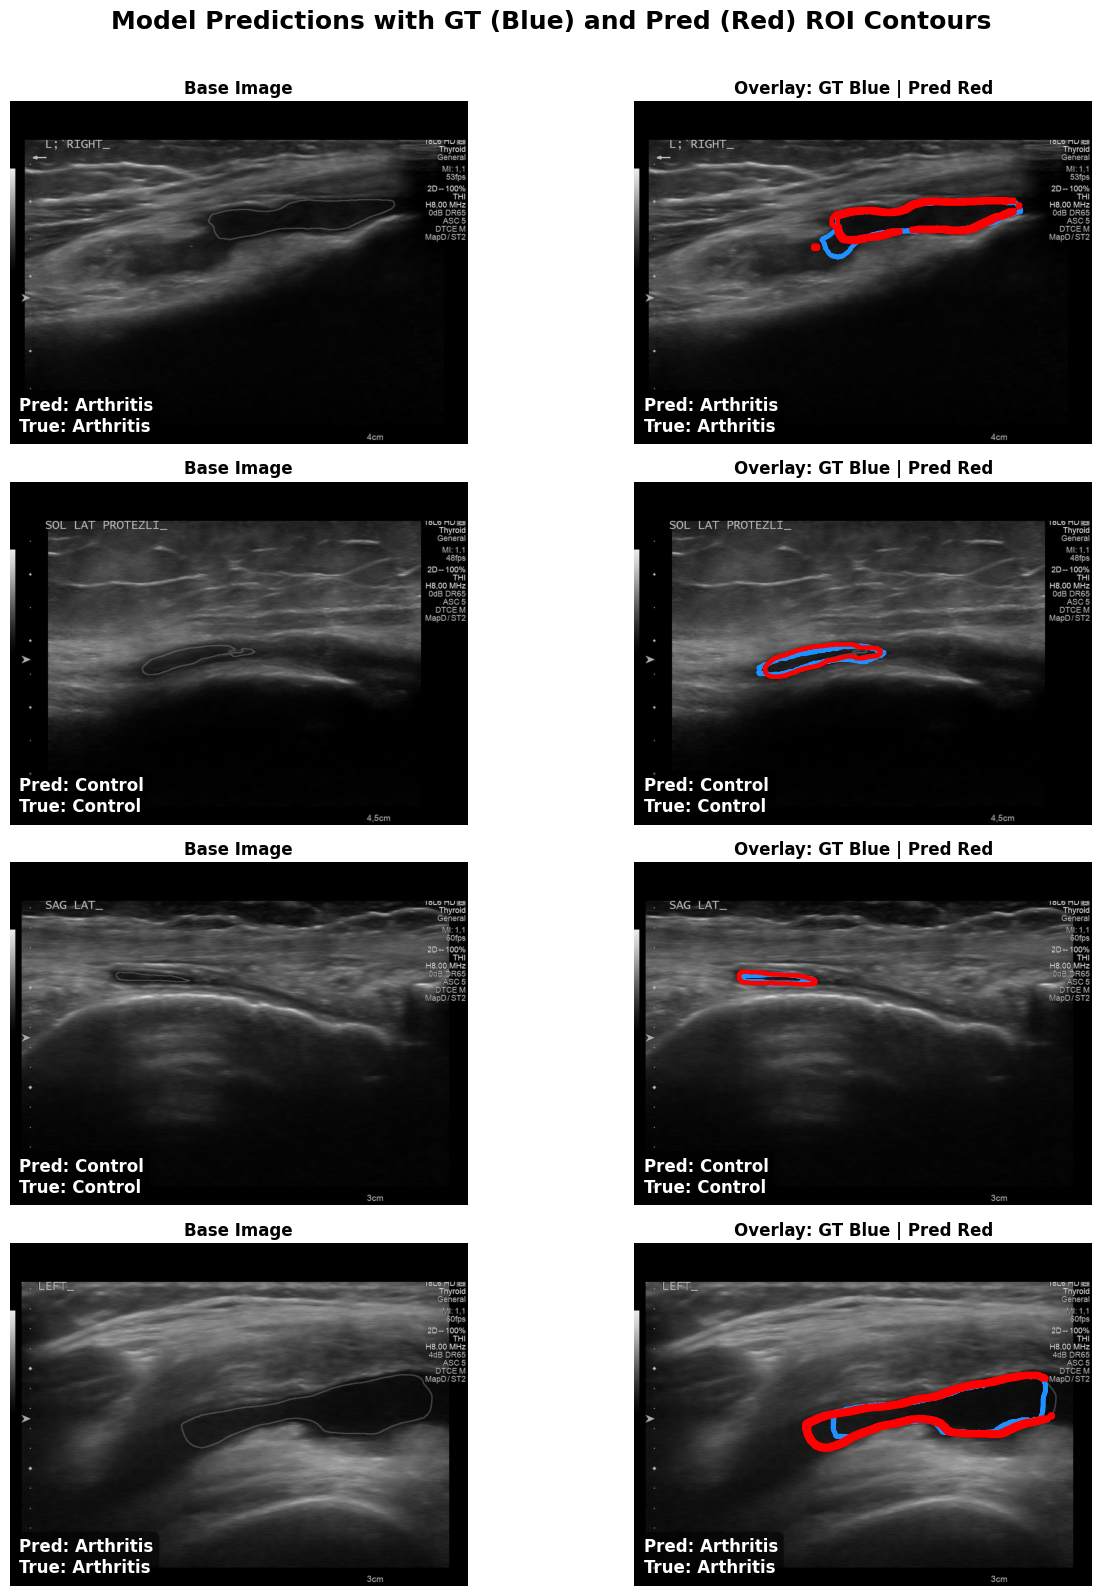

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def pred_mask_from_pred_image(pred_img_rgb):
    x = pred_img_rgb.astype(np.int16)
    r, g, b = x[..., 0], x[..., 1], x[..., 2]
    green = (g > 110) & (g > r + 35) & (g > b + 35)
    if green.sum() == 0:
        return None
    m = (green.astype(np.uint8) * 255)
    m = cv2.dilate(m, np.ones((3, 3), np.uint8), iterations=2)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8), iterations=2)
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled = np.zeros_like(m)
    if len(cnts) > 0:
        cv2.drawContours(filled, cnts, -1, 255, thickness=-1)
        return filled > 0
    return m > 0

def to_gray_rgb(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    return np.stack([gray, gray, gray], axis=-1)

def draw_contours(ax, mask_bool, color, lw=3.0):
    if mask_bool is None:
        return
    m = mask_bool.astype(np.uint8)
    if m.sum() == 0:
        return
    ax.contour(m, levels=[0.5], colors=[color], linewidths=lw)

def put_pred_true(ax, pred_text, true_text, fs=12):
    ax.text(
        0.02, 0.04,
        f"Pred: {pred_text}\nTrue: {true_text}",
        transform=ax.transAxes,
        fontsize=fs, fontweight='bold', color='white',
        bbox=dict(boxstyle="round,pad=0.35", facecolor="black", alpha=0.55, edgecolor="none")
    )

n = len(pred_images)
fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n))
axes = np.atleast_2d(axes)

for i, pred_filename in enumerate(pred_images):
    pred_img, gt_mask, info = load_images(pred_filename)
    if pred_img is None:
        axes[i, 0].axis('off')
        axes[i, 1].axis('off')
        continue

    pred_img_rgb = pred_img
    base = to_gray_rgb(pred_img_rgb)

    gt = (gt_mask > 0) if gt_mask is not None else None
    pr = pred_mask_from_pred_image(pred_img_rgb)

    ax0 = axes[i, 0]
    ax0.imshow(base)
    put_pred_true(ax0, info['pred_class'], info['true_class'], fs=12)
    ax0.set_title("Base Image", fontsize=12, fontweight='bold', color='black')
    ax0.axis('off')

    ax1 = axes[i, 1]
    ax1.imshow(base)
    draw_contours(ax1, gt, color='dodgerblue', lw=3.2)
    draw_contours(ax1, pr, color='red', lw=3.2)
    put_pred_true(ax1, info['pred_class'], info['true_class'], fs=12)
    ax1.set_title("Overlay: GT Blue | Pred Red", fontsize=12, fontweight='bold', color='black')
    ax1.axis('off')

plt.suptitle(
    "Model Predictions with GT (Blue) and Pred (Red) ROI Contours",
    fontsize=18, fontweight='bold', y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.985])

output_path = FIGURES_DIR / "Figure_Prediction_vs_GroundTruth_ROI_BlueRed_Pairs.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"\nFigure saved to: {output_path}")
plt.show()


## Individual Detailed Figures

Create separate 3-panel figures for each prediction.

Saved: /home/zera/Desktop/data_fold/test_evaluation_figures/image_005_R_P_001_pred_arthrit_with_GT_ROI.png


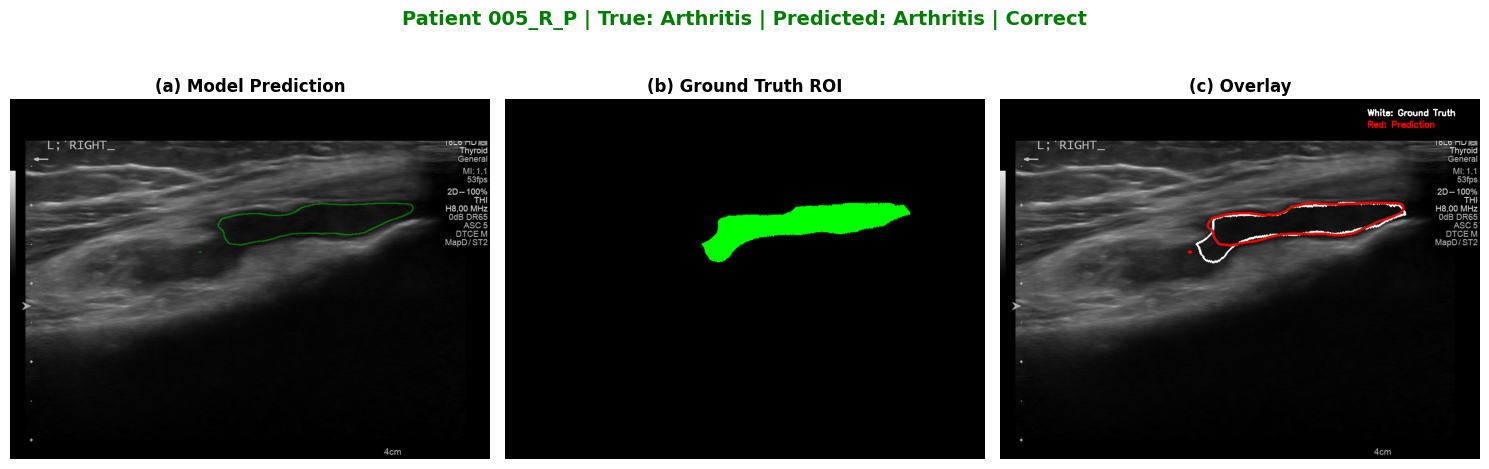

Saved: /home/zera/Desktop/data_fold/test_evaluation_figures/image_008_L_C_001_pred_control_with_GT_ROI.png


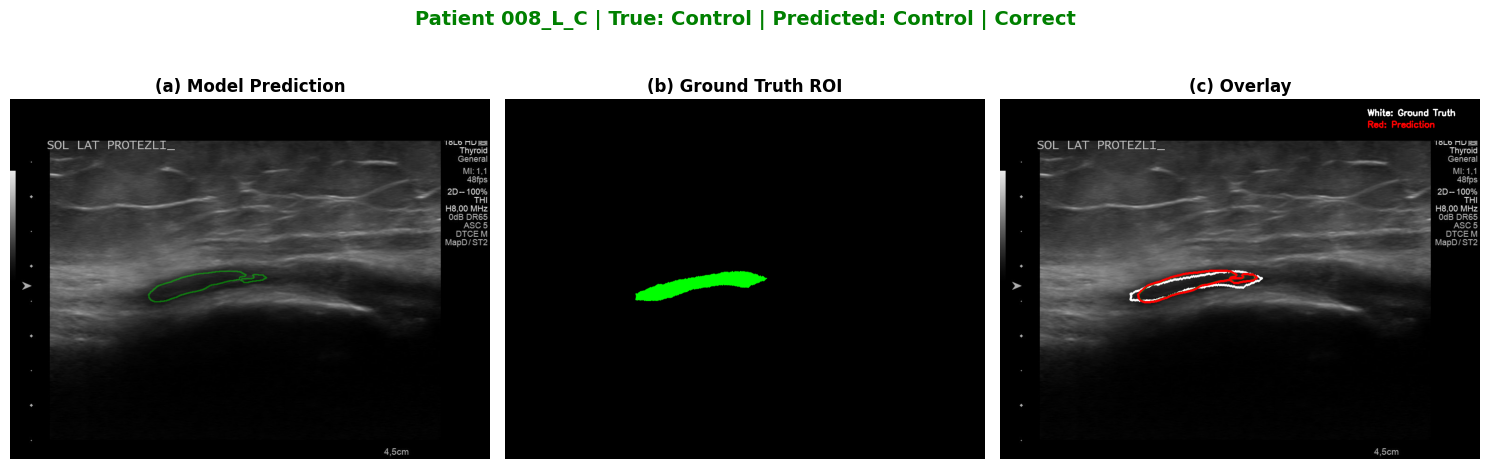

Saved: /home/zera/Desktop/data_fold/test_evaluation_figures/image_016_R_C_001_pred_control_with_GT_ROI.png


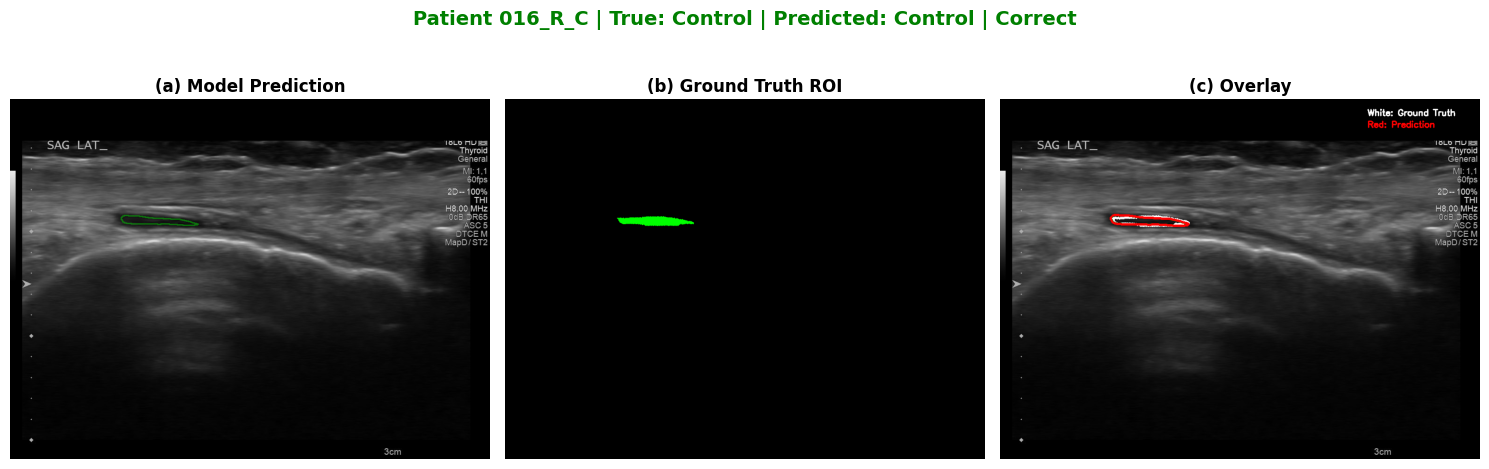

Saved: /home/zera/Desktop/data_fold/test_evaluation_figures/image_017_L_P_001_pred_arthrit_with_GT_ROI.png


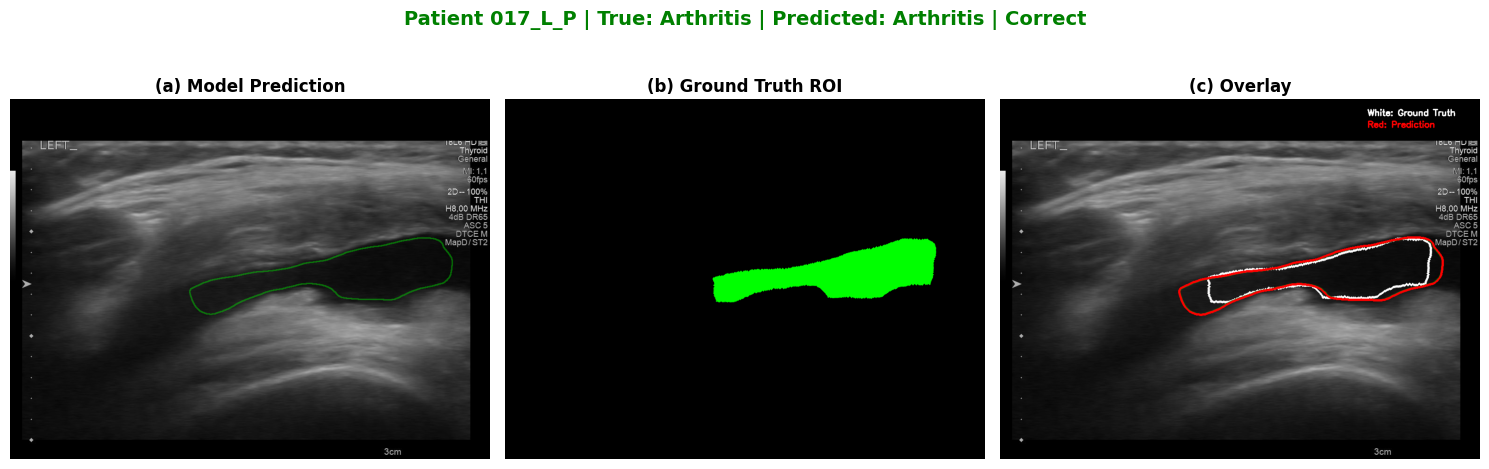


✓ All figures generated successfully!


In [ ]:
for pred_filename in pred_images:
    pred_img, roi_mask, info = load_images(pred_filename)
    
    if pred_img is None:
        continue
    
    # Create figure with 3 panels
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    is_correct = info['true_class'] == info['pred_class']
    status = "Correct" if is_correct else "Incorrect"
    
    # Panel 1: Original prediction
    axes[0].imshow(pred_img)
    axes[0].set_title('(a) Model Prediction', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Panel 2: Ground truth ROI only
    if roi_mask is not None:
        roi_display = np.zeros_like(pred_img)
        roi_display[roi_mask > 0] = [0, 255, 0]
        axes[1].imshow(roi_display)
        axes[1].set_title('(b) Ground Truth ROI', fontsize=12, fontweight='bold')
    else:
        axes[1].text(0.5, 0.5, 'ROI Not Available', 
                    ha='center', va='center', fontsize=14)
        axes[1].set_title('(b) Ground Truth ROI', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    # Panel 3: Overlay
    overlaid = overlay_ground_truth(pred_img, roi_mask)
    axes[2].imshow(overlaid)
    axes[2].set_title('(c) Overlay', fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    # Overall title
    fig.suptitle(
        f"Patient {info['patient_id']} | True: {info['true_class']} | Predicted: {info['pred_class']} | {status}",
        fontsize=14, fontweight='bold', 
        color='green' if is_correct else 'red'
    )
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    # Save individual figure
    output_name = pred_filename.replace('.png', '_with_GT_ROI.png')
    output_path = FIGURES_DIR / output_name
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {output_path}")
    
    plt.show()

print("\n✓ All figures generated successfully!")

---

## Mask R-CNN — Qualitative Segmentation Overlays (Figure 5)

Ground-truth contours (white) overlaid on Mask R-CNN predictions (red). A 2×2 grid of representative test images from selected patients.


In [21]:
# -*- coding: utf-8 -*-
"""
Mask R-CNN Overlay & Grid Visualization
---------------------------------------
This notebook processes pairs of ultrasound images and Mask R-CNN predictions.
It draws the Ground Truth (White Contour) and Model Prediction (Red Contour)
masks onto the original ultrasound image.
Finally, it displays the original image and the generated overlay side-by-side
in a 2x2 grid format and saves it.
"""

'\nMask R-CNN Overlay & Grid Visualization\n---------------------------------------\nThis notebook processes pairs of ultrasound images and Mask R-CNN predictions.\nIt draws the Ground Truth (White Contour) and Model Prediction (Red Contour)\nmasks onto the original ultrasound image.\nFinally, it displays the original image and the generated overlay side-by-side\nin a 2x2 grid format and saves it.\n'

In [24]:
overlay_paths = {}
print("Generating overlays...")
for img_name in IMAGES_TO_PROCESS:
    res = create_hollow_overlay(img_name)
    if res:
        overlay_paths[img_name] = res
        print(f"Created: {res}")

Generating overlays...
Created: /home/zera/Desktop/data_fold/maskrcnn/output_overlays/hollow_image_005_R_P_001.png
Created: /home/zera/Desktop/data_fold/maskrcnn/output_overlays/hollow_image_006_R_P_003.png


Grid image successfully saved: /home/zera/Desktop/data_fold/maskrcnn/output_overlays/mrcnn_2x2_comparison.png


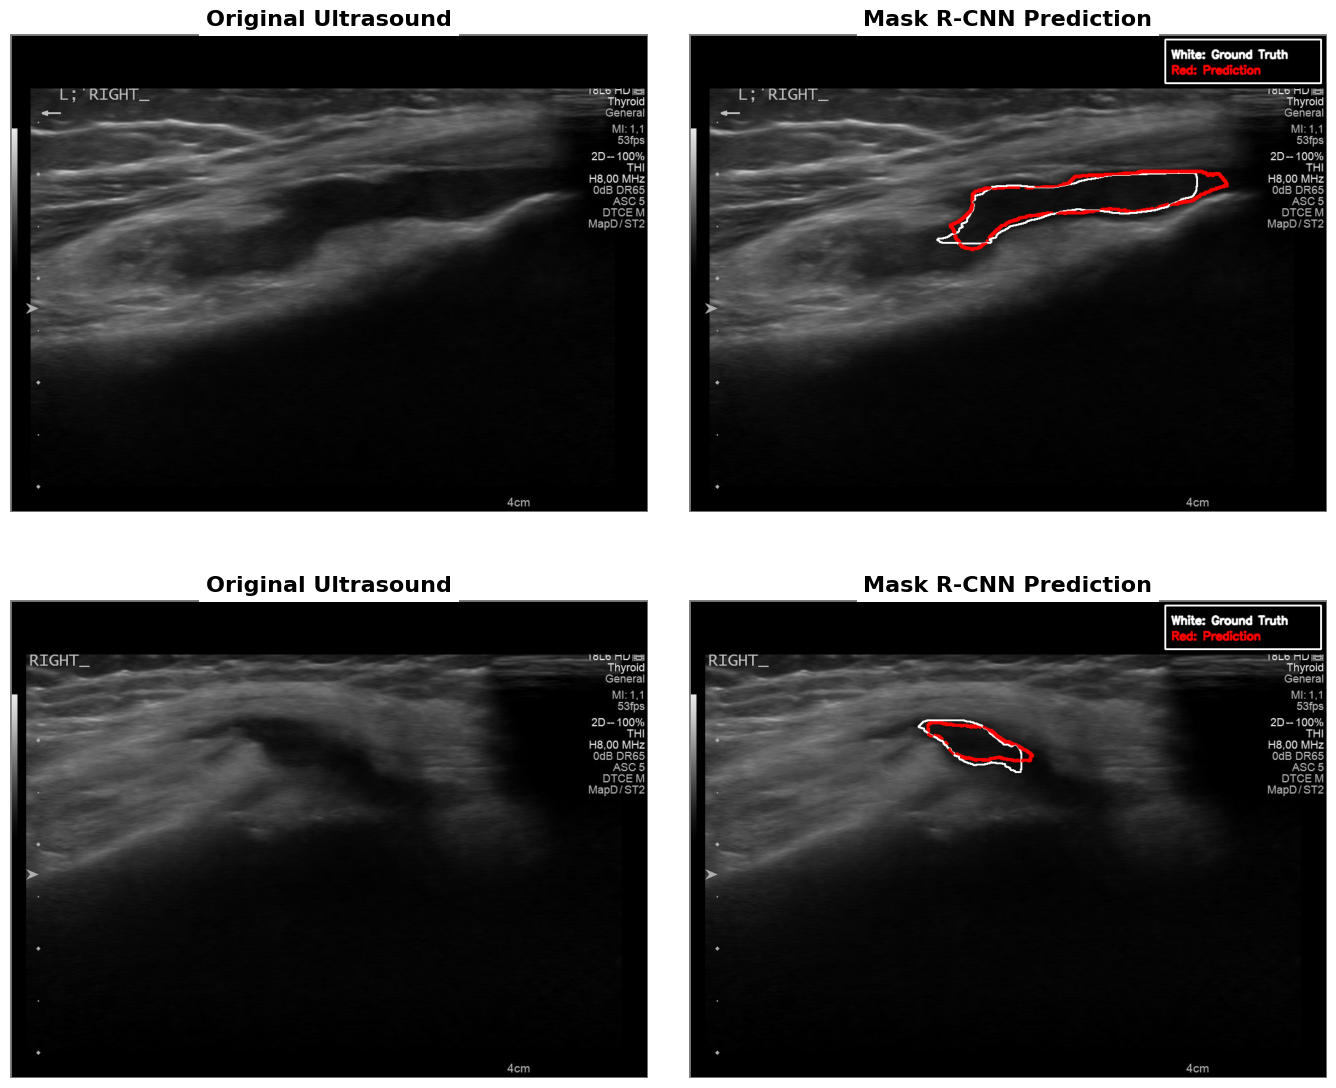

In [25]:
grid_out_path = os.path.join(OUT_DIR, 'mrcnn_2x2_comparison.png')
# Use a non-transparent figure to avoid black text on black background when pasting to slides
fig, axes = plt.subplots(len(IMAGES_TO_PROCESS), 2, figsize=(14, 6 * len(IMAGES_TO_PROCESS)))
fig.patch.set_facecolor('white') # Solid white background

for i, img_name in enumerate(IMAGES_TO_PROCESS):
    base_path = os.path.join(BASE_DIR, img_name)
    overlay_path = overlay_paths.get(img_name)
    
    # Read Base Image
    if os.path.exists(base_path):
        base_img = cv2.imread(base_path)
        base_img = cv2.cvtColor(base_img, cv2.COLOR_BGR2RGB)
    else:
        base_img = np.zeros((100, 100, 3), dtype=np.uint8)
    
    # Read Overlay Image
    if overlay_path and os.path.exists(overlay_path):
        overlay_img = cv2.imread(overlay_path)
        overlay_img = cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB)
    else:
        overlay_img = np.zeros((100, 100, 3), dtype=np.uint8)
    
    # Column 1 (Left): Original Image
    ax_base = axes[i, 0] if len(IMAGES_TO_PROCESS) > 1 else axes[0]
    ax_base.imshow(base_img)
    # Add white background to titles so they show up perfectly when copying
    ax_base.set_title('Original Ultrasound', fontsize=16, fontweight='bold', color='black', 
                      bbox=dict(facecolor='white', alpha=1.0, pad=5, edgecolor='none'))
    ax_base.axis('off')
    
    rect_base = plt.Rectangle((0,0), 1, 1, fill=False, color='gray', lw=2, transform=ax_base.transAxes)
    ax_base.add_patch(rect_base)
    
    # Column 2 (Right): Hollow Mask Overlay
    ax_ov = axes[i, 1] if len(IMAGES_TO_PROCESS) > 1 else axes[1]
    ax_ov.imshow(overlay_img)
    # Explanatory title matching user request
    ax_ov.set_title('Mask R-CNN Prediction', fontsize=16, fontweight='bold', color='black',
                    bbox=dict(facecolor='white', alpha=1.0, pad=5, edgecolor='none'))
    ax_ov.axis('off')
    
    rect_ov = plt.Rectangle((0,0), 1, 1, fill=False, color='gray', lw=2, transform=ax_ov.transAxes)
    ax_ov.add_patch(rect_ov)

plt.tight_layout(pad=3.0)
# DO NOT use transparent=True here, so it pastes safely onto dark slides without vanishing text
plt.savefig(grid_out_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Grid image successfully saved: {grid_out_path}")
plt.show() # Display inline in Jupyter

In [24]:
overlay_paths = {}
print("Generating overlays...")
for img_name in IMAGES_TO_PROCESS:
    res = create_hollow_overlay(img_name)
    if res:
        overlay_paths[img_name] = res
        print(f"Created: {res}")

Generating overlays...
Created: /home/zera/Desktop/data_fold/maskrcnn/output_overlays/hollow_image_005_R_P_001.png
Created: /home/zera/Desktop/data_fold/maskrcnn/output_overlays/hollow_image_006_R_P_003.png


Grid image successfully saved: /home/zera/Desktop/data_fold/maskrcnn/output_overlays/mrcnn_2x2_comparison.png


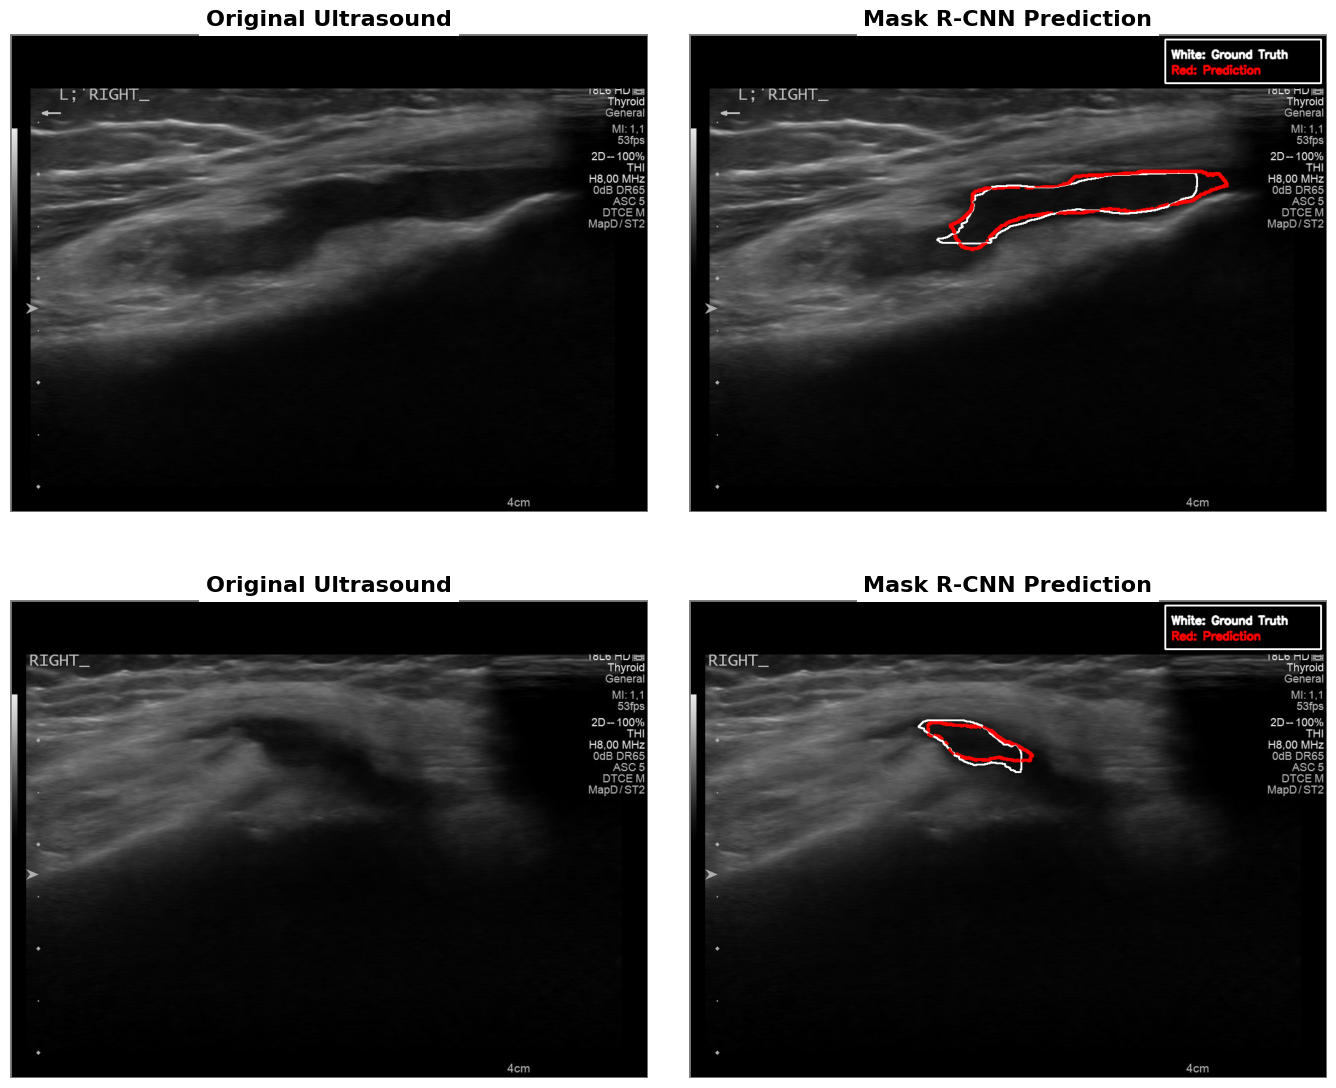

In [25]:
grid_out_path = os.path.join(OUT_DIR, 'mrcnn_2x2_comparison.png')
# Use a non-transparent figure to avoid black text on black background when pasting to slides
fig, axes = plt.subplots(len(IMAGES_TO_PROCESS), 2, figsize=(14, 6 * len(IMAGES_TO_PROCESS)))
fig.patch.set_facecolor('white') # Solid white background

for i, img_name in enumerate(IMAGES_TO_PROCESS):
    base_path = os.path.join(BASE_DIR, img_name)
    overlay_path = overlay_paths.get(img_name)
    
    # Read Base Image
    if os.path.exists(base_path):
        base_img = cv2.imread(base_path)
        base_img = cv2.cvtColor(base_img, cv2.COLOR_BGR2RGB)
    else:
        base_img = np.zeros((100, 100, 3), dtype=np.uint8)
    
    # Read Overlay Image
    if overlay_path and os.path.exists(overlay_path):
        overlay_img = cv2.imread(overlay_path)
        overlay_img = cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB)
    else:
        overlay_img = np.zeros((100, 100, 3), dtype=np.uint8)
    
    # Column 1 (Left): Original Image
    ax_base = axes[i, 0] if len(IMAGES_TO_PROCESS) > 1 else axes[0]
    ax_base.imshow(base_img)
    # Add white background to titles so they show up perfectly when copying
    ax_base.set_title('Original Ultrasound', fontsize=16, fontweight='bold', color='black', 
                      bbox=dict(facecolor='white', alpha=1.0, pad=5, edgecolor='none'))
    ax_base.axis('off')
    
    rect_base = plt.Rectangle((0,0), 1, 1, fill=False, color='gray', lw=2, transform=ax_base.transAxes)
    ax_base.add_patch(rect_base)
    
    # Column 2 (Right): Hollow Mask Overlay
    ax_ov = axes[i, 1] if len(IMAGES_TO_PROCESS) > 1 else axes[1]
    ax_ov.imshow(overlay_img)
    # Explanatory title matching user request
    ax_ov.set_title('Mask R-CNN Prediction', fontsize=16, fontweight='bold', color='black',
                    bbox=dict(facecolor='white', alpha=1.0, pad=5, edgecolor='none'))
    ax_ov.axis('off')
    
    rect_ov = plt.Rectangle((0,0), 1, 1, fill=False, color='gray', lw=2, transform=ax_ov.transAxes)
    ax_ov.add_patch(rect_ov)

plt.tight_layout(pad=3.0)
# DO NOT use transparent=True here, so it pastes safely onto dark slides without vanishing text
plt.savefig(grid_out_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Grid image successfully saved: {grid_out_path}")
plt.show() # Display inline in Jupyter